In [23]:
%cd /content

/content


In [24]:
!git clone https://github.com/pravaspaudel/Dual_watermarking_Scheme.git

fatal: destination path 'Dual_watermarking_Scheme' already exists and is not an empty directory.


In [25]:
%cd Dual_watermarking_Scheme

/content/Dual_watermarking_Scheme


In [26]:
import math
from collections import Counter

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.metrics import roc_curve, auc

from huggingface_hub import login

from src.utils.model import load_model
from src.utils.loadConfig import load_config
from src.utils.key_manager import generate_key, derive_set
from src.watermark.dual_layer import DualWaterMarking

In [27]:
# ============================================================
# CONFIGURATION - single source of truth for the whole notebook.
# N_SAMPLES = 10  -> smoke test. Manually change to 100 for the final run
# ONLY after every sanity check below passes.
# ============================================================
N_SAMPLES = 10             # smoke test; change to 100 for the final run
PUBLIC_DELTAS = [0.0, 0.3, 0.7, 1.2, 2.0]
PRIVATE_DELTA_FIXED = 0.7
ROC_LENGTH = 350           # max_new_tokens for the ROC watermarked class
FP_MAX_SAMPLES = 500       # clean samples for FP calibration
CLEAN_MIN_WORDS = 30       # NO upper bound (old 30-80 filter left only n=2)
CLEAN_MAX_TOKENS = 200     # detector-valid truncation for clean texts
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

df_c4 = pd.read_parquet("data/extracted/c4_samples.parquet")
assert {"prompt_text", "reference_text"}.issubset(df_c4.columns), "unexpected parquet schema"

# Fixed prompt set - the SAME prompts are reused across every delta_public value
prompts = [str(p) for p in df_c4["prompt_text"].dropna() if str(p).strip()][:N_SAMPLES]
assert len(prompts) >= 3, "only %d valid prompts available" % len(prompts)

print(f"N_SAMPLES         : {N_SAMPLES}")
print(f"C4 rows available : {len(df_c4)}")
print(f"prompts loaded    : {len(prompts)}")
print(f"sample prompt     : {prompts[0][:110]!r}")
_pw = [len(p.split()) for p in prompts]
print(f"prompt words      : min={min(_pw)} median={int(np.median(_pw))} max={max(_pw)}")


N_SAMPLES         : 10
C4 rows available : 1000
prompts loaded    : 10
sample prompt     : '"Whoever gets him, they\'ll be getting a good one," David Montgomery said.\nINDIANAPOLIS — Hakeem Butler has bee'
prompt words      : min=32 median=36 max=44


In [28]:
# ============================================================
# CLEAN C4 TEXTS (non-watermarked negatives)
# word_count >= CLEAN_MIN_WORDS, NO 80-word cap (the old 30-80 filter
# left only n=2 clean samples, which made every FPR=0 meaningless).
# The FP-calibration slice and the ROC-negative slice are DISJOINT.
# ============================================================
def load_clean_c4_texts(df, n, min_words=CLEAN_MIN_WORDS):
    texts, wc = [], []
    for t in df["reference_text"].dropna():
        t = str(t).strip()
        w = len(t.split())
        if w >= min_words:
            texts.append(t)
            wc.append(w)
        if len(texts) >= n:
            break
    return texts, wc

all_clean, all_wc = load_clean_c4_texts(df_c4, FP_MAX_SAMPLES + N_SAMPLES)
clean_texts_fp = all_clean[:FP_MAX_SAMPLES]        # FP calibration slice
clean_texts_roc = all_clean[FP_MAX_SAMPLES:]       # ROC negatives (disjoint)

print(f"clean texts (FP calibration) : {len(clean_texts_fp)}")
print(f"clean texts (ROC negatives)  : {len(clean_texts_roc)}  (disjoint from FP slice)")
if all_wc:
    print(f"clean word counts : min={min(all_wc)} median={int(np.median(all_wc))} max={max(all_wc)}")
if len(clean_texts_fp) < 50:
    print("WARNING: <50 clean FP samples -> FP calibration too small for meaningful interpretation")
if len(clean_texts_roc) < N_SAMPLES:
    print(f"WARNING: only {len(clean_texts_roc)} ROC negatives available (< {N_SAMPLES})")


clean texts (FP calibration) : 500
clean texts (ROC negatives)  : 10  (disjoint from FP slice)
clean word counts : min=78 median=153 max=180


In [29]:
login()

config = load_config("secondLayer")
device = "cuda" if torch.cuda.is_available() else "cpu"

model, tokenizer, vocab_size = load_model(config["MODEL_NAME"])
model.to(device)
    
key = generate_key()

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

model and tokenizer of facebook/opt-2.7b loaded with vocab_size 50265


In [30]:
dwm = DualWaterMarking(
    model=model,
    tokenizer=tokenizer,
    key=key,
    greenlist_dir="data/greenlist",  # per-topic CSVs (history.csv, science.csv, ...)
    green_fraction=config["GREEN_FRACTION"],
    delta_public=2.0,
    delta_private=PRIVATE_DELTA_FIXED,
    w1=1.0,
    w2=1.0,
    prev_token_size=config["PREV_TOKEN_SIZE"],
    max_new_tokens=50,
)

# explicit starting point for the delta_public sweep below
dwm.delta_public = 2.0
dwm.delta_private = PRIVATE_DELTA_FIXED   # NOTE: attribute is delta_private (old code set delta_priv, which the class ignores)

# prompts come from the CONFIGURATION cell (C4 parquet) - no hardcoded prompts
torch.manual_seed(SEED)
gen_df = dwm.watermark(prompts, include_single_layers=True)
print(f"generated outputs : {len(gen_df)} rows, columns = {gen_df.columns.tolist()}")
assert (gen_df["dual_watermarked_output"].str.len() > 0).all(), "zero-length watermarked generation found"
assert (gen_df["plain_output"].str.len() > 0).all(), "zero-length plain generation found"
gen_df.head()


generated outputs : 10 rows, columns = ['id', 'prompt', 'topic', 'topic_score', 'plain_output', 'dual_watermarked_output', 'layer1_only_output', 'layer2_only_output']


,id,prompt,topic,topic_score,plain_output,dual_watermarked_output,layer1_only_output,layer2_only_output
0,0,"""Whoever gets him, they'll be getting a good o...",history,0.2640,"""Whoever gets him, they'll be getting a good o...","""Whoever gets him, they'll be getting a good o...","""Whoever gets him, they'll be getting a good o...","""Whoever gets him, they'll be getting a good o..."
1,1,8i announced today it has launched a web playe...,technology,0.2905,8i announced today it has launched a web playe...,8i announced today it has launched a web playe...,8i announced today it has launched a web playe...,8i announced today it has launched a web playe...
2,2,The Arlington County Board plans to vote Satur...,history,0.2564,The Arlington County Board plans to vote Satur...,The Arlington County Board plans to vote Satur...,The Arlington County Board plans to vote Satur...,The Arlington County Board plans to vote Satur...
3,3,The Hawaii man who was fired after issuing the...,history,0.2557,The Hawaii man who was fired after issuing the...,The Hawaii man who was fired after issuing the...,The Hawaii man who was fired after issuing the...,The Hawaii man who was fired after issuing the...
4,4,Shania Twain expected to break the charts with...,history,0.2528,Shania Twain expected to break the charts with...,Shania Twain expected to break the charts with...,Shania Twain expected to break the charts with...,Shania Twain expected to break the charts with...


In [31]:
def _ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))


def distinct_n(texts, n):
    """distinct-n over a LIST of texts: unique n-grams / total n-grams."""
    all_ngrams = []
    for t in texts:
        tokens = t.split()
        all_ngrams.extend(_ngrams(tokens, n))
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


def repetition_rate(text, n=3):
    """
    Fraction of n-grams in `text` that are repeats of an earlier n-gram
    in the same text. High values at high delta = watermark is forcing
    the model into repetitive loops to hit greenlist tokens.
    """
    tokens = text.split()
    grams = _ngrams(tokens, n)
    if not grams:
        return 0.0
    counts = Counter(grams)
    repeated = sum(c - 1 for c in counts.values() if c > 1)
    return repeated / len(grams)

In [32]:
for col in ["plain_output", "dual_watermarked_output"]:
    d1 = distinct_n(gen_df[col].tolist(), 1)
    d2 = distinct_n(gen_df[col].tolist(), 2)
    rr = np.mean([repetition_rate(t) for t in gen_df[col]])
    print(f"{col:26s} distinct-1={d1:.3f}  distinct-2={d2:.3f}  mean-repetition={rr:.3f}")

plain_output               distinct-1=0.601  distinct-2=0.950  mean-repetition=0.001
dual_watermarked_output    distinct-1=0.608  distinct-2=0.961  mean-repetition=0.003


In [33]:
def run_multi_seed(generate_fn, prompts, seeds, extra_cols_fn=None):
    """
    Generic helper to build a DataFrame across multiple prompts x seeds
    using YOUR OWN generation function.

    generate_fn(prompt) -> dict
        Should return a dict of one row's worth of outputs, e.g.
        {"plain_output": "...", "watermarked_output": "..."}

    seeds: a LIST of ints, e.g. [0, 1, 2]  (NOT an integer count)
    prompts: a LIST of prompt strings

    extra_cols_fn(prompt) -> dict, optional
        For attaching extra grouping columns per prompt, e.g. {"topic": "science"}.

    Returns a DataFrame with columns: prompt, seed, <whatever generate_fn returns>, <extra cols>
    """
    rows = []
    for seed in seeds:          # iterate the seed VALUES, not range(seeds)
        for prompt in prompts:  # iterate the prompt STRINGS, not range(prompts)
            torch.manual_seed(seed)
            out = generate_fn(prompt)

            row = {"prompt": prompt, "seed": seed, **out}
            if extra_cols_fn is not None:
                row.update(extra_cols_fn(prompt))

            rows.append(row)

    return pd.DataFrame(rows)

In [34]:
def load_judge_model(judge_model_name="gpt2-large", device="cuda"):
    """Loads an external judge model + tokenizer, used only to score perplexity."""
    from transformers import AutoModelForCausalLM, AutoTokenizer

    judge_tokenizer = AutoTokenizer.from_pretrained(judge_model_name)
    judge_model = AutoModelForCausalLM.from_pretrained(judge_model_name)
    judge_model.to(device)
    judge_model.eval()
    return judge_model, judge_tokenizer


def split_continuation(prompt, full_text):
    """Return just the generated continuation, stripping the prompt prefix."""
    if full_text.startswith(prompt):
        return full_text[len(prompt):].strip()
    idx = full_text.find(prompt)
    if idx != -1:
        return full_text[idx + len(prompt):].strip()
    return full_text.strip()


def _continuation_perplexity(prompt, continuation, scorer_model, scorer_tokenizer, device):
    """Shared implementation for external + self perplexity: perplexity of
    `continuation`'s tokens only, conditioned on `prompt` as context (prompt
    tokens are excluded from the loss)."""
    if not continuation.strip():
        return float("nan")

    prompt_ids = scorer_tokenizer.encode(prompt, add_special_tokens=False)
    cont_ids = scorer_tokenizer.encode(continuation, add_special_tokens=False)
    if len(cont_ids) == 0:
        return float("nan")

    input_ids = torch.tensor([prompt_ids + cont_ids], device=device)

    with torch.no_grad():
        outputs = scorer_model(input_ids)

    logits = outputs.logits
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = input_ids[..., 1:].contiguous()

    token_losses = torch.nn.functional.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        reduction="none",
    )

    # after the shift-by-1, the loss at index i predicts token i+1 of the
    # original sequence, so the continuation's first token's loss sits at
    # index len(prompt_ids) - 1
    start = max(len(prompt_ids) - 1, 0)
    cont_losses = token_losses[start:]
    if cont_losses.numel() == 0:
        return float("nan")

    return math.exp(cont_losses.mean().item())


def compute_external_perplexity(prompt, continuation, judge_model, judge_tokenizer, device):
    """Perplexity of `continuation` under the independent judge model."""
    return _continuation_perplexity(prompt, continuation, judge_model, judge_tokenizer, device)


def compute_self_perplexity(prompt, continuation, self_model, self_tokenizer, device):
    """Perplexity of `continuation` under the same model that generated it (OPT)."""
    return _continuation_perplexity(prompt, continuation, self_model, self_tokenizer, device)

In [35]:
def evaluate_quality_table(
    df,
    prompt_col="prompt",
    text_cols=("plain_output", "dual_watermarked_output"),
    judge_model_name="gpt2-large",
    device="cuda",
    group_cols=None,
    self_model=None,
    self_tokenizer=None,
):
    """
    Computes per-row quality metrics for each text column, then returns:
      - metrics_df: one row per (original row, variant) with raw metrics
      - summary_df: mean +/- std of each metric, grouped by variant
                    (+ any extra group_cols like 'topic', 'seed', 'delta')

    text_cols entries are treated as "variant" labels in the output
    (e.g. "plain_output" -> variant "plain_output").

    self_model / self_tokenizer: OPTIONAL. Pass your generation model
    (e.g. OPT) + its tokenizer to also compute self-perplexity alongside
    the required external perplexity. Leave as None to skip it.
    """
    judge_model, judge_tokenizer = load_judge_model(judge_model_name, device)

    records = []
    for _, row in df.iterrows():
        prompt = row[prompt_col]
        for col in text_cols:
            full_text = row[col]
            cont = split_continuation(prompt, full_text)

            ext_ppl = compute_external_perplexity(prompt, cont, judge_model, judge_tokenizer, device)

            rec = {
                "variant": col,
                "external_perplexity": ext_ppl,
                "distinct_1": distinct_n([cont], 1),
                "distinct_2": distinct_n([cont], 2),
                "distinct_3": distinct_n([cont], 3),
                "repetition_rate": repetition_rate(cont),
            }

            if self_model is not None and self_tokenizer is not None:
                rec["self_perplexity"] = compute_self_perplexity(
                    prompt, cont, self_model, self_tokenizer, device
                )

            if group_cols:
                for g in group_cols:
                    rec[g] = row[g]

            records.append(rec)

    metrics_df = pd.DataFrame(records)

    group_by = ["variant"] + (list(group_cols) if group_cols else [])
    summary_df = metrics_df.groupby(group_by).agg(["mean", "std"]).round(4)

    return metrics_df, summary_df

In [36]:
# Robust summary: NaN/inf excluded from mean/std; n_valid / n_invalid reported.
def summarize_valid(metrics_df, exclude_cols=("delta_public",)):
    value_cols = [c for c in metrics_df.columns
                  if pd.api.types.is_numeric_dtype(metrics_df[c]) and c not in exclude_cols]
    rows = []
    for col in value_cols:
        s = pd.to_numeric(metrics_df[col], errors="coerce")
        valid = s[np.isfinite(s)]
        rows.append({
            "metric": col,
            "n_valid": int(len(valid)),
            "n_invalid(NaN/inf)": int(len(s) - len(valid)),
            "mean": valid.mean() if len(valid) else float("nan"),
            "std": valid.std() if len(valid) > 1 else float("nan"),
        })
    return pd.DataFrame(rows).set_index("metric")

metrics_df, summary_df = evaluate_quality_table(
    gen_df,
    text_cols=("plain_output", "dual_watermarked_output"),
    judge_model_name="gpt2-large",
    device=device,
    self_model=model,
    self_tokenizer=tokenizer,
)

print("=== per-metric validity summary (NaN/inf excluded from mean/std) ===")
print(summarize_valid(metrics_df).round(4))

# extreme perplexity outliers - one bad generation must not silently dominate the mean
for variant, grp in metrics_df.groupby("variant"):
    s = pd.to_numeric(grp["external_perplexity"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 2:
        out_mask = s > s.mean() + 3 * s.std()
        if out_mask.any():
            print(f"\nOUTLIERS external_perplexity > mean+3sd [{variant}]:")
            for i in s[out_mask].index:
                print(f"  metrics row {i}: ppl={s[i]:.1f}")
        else:
            print(f"\nno extreme perplexity outliers in [{variant}]")

summary_df


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

=== per-metric validity summary (NaN/inf excluded from mean/std) ===
                     n_valid  n_invalid(NaN/inf)     mean     std
metric                                                           
external_perplexity       20                   0  11.9963  4.7318
distinct_1                20                   0   0.8671  0.0495
distinct_2                20                   0   0.9927  0.0164
distinct_3                20                   0   1.0000  0.0000
repetition_rate           20                   0   0.0000  0.0000
self_perplexity           20                   0   7.2590  2.9514

no extreme perplexity outliers in [dual_watermarked_output]

no extreme perplexity outliers in [plain_output]


external_perplexity         distinct_1          \
                                       mean     std       mean     std   
variant                                                                  
dual_watermarked_output             12.5622  4.4451     0.8695  0.0396   
plain_output                        11.4304  5.1765     0.8647  0.0599   

                        distinct_2         distinct_3      repetition_rate  \
                              mean     std       mean  std            mean   
variant                                                                      
dual_watermarked_output     0.9940  0.0128        1.0  0.0             0.0   
plain_output                0.9914  0.0200        1.0  0.0             0.0   

                             self_perplexity          
                         std            mean     std  
variant                                               
dual_watermarked_output  0.0          7.9041  3.4869  
plain_output             0.0          6.6139  2.3035

In [37]:
def plot_perplexity_vs_delta(delta_to_metrics_df, variant="dual_watermarked_output",
                              metric="external_perplexity", save_path=None):
    """
    GRAPH 1: Perplexity vs delta_public, mean +/- std error bars.
    delta_to_metrics_df: dict[delta_public -> metrics_df from evaluate_quality_table]
    NaN/inf are excluded from the statistics; per-point sample counts in the legend.
    No smoothing; no forced monotonic trend.
    """
    deltas = sorted(delta_to_metrics_df.keys())
    means, stds, ns = [], [], []
    for d in deltas:
        sub = delta_to_metrics_df[d]
        sub = sub[sub["variant"] == variant]
        s = pd.to_numeric(sub[metric], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        means.append(s.mean() if len(s) else float("nan"))
        stds.append(s.std() if len(s) > 1 else 0.0)
        ns.append(len(s))

    labels = [f"d={d} (n={n})" for d, n in zip(deltas, ns)]
    plt.figure(figsize=(7, 4))
    plt.errorbar(deltas, means, yerr=stds, marker="o", capsize=4,
                 label="; ".join(labels))
    plt.xlabel("delta_public")
    plt.ylabel(f"Perplexity ({metric})")
    plt.title(f"Perplexity vs delta_public  [{variant}]")
    plt.legend(fontsize=7)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

delta_public=0.0: n_valid_ppl=10  mean_ext_ppl=10.83


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

delta_public=0.3: n_valid_ppl=10  mean_ext_ppl=11.17


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

delta_public=0.7: n_valid_ppl=10  mean_ext_ppl=11.90


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

delta_public=1.2: n_valid_ppl=10  mean_ext_ppl=9.91


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

delta_public=2.0: n_valid_ppl=10  mean_ext_ppl=15.67


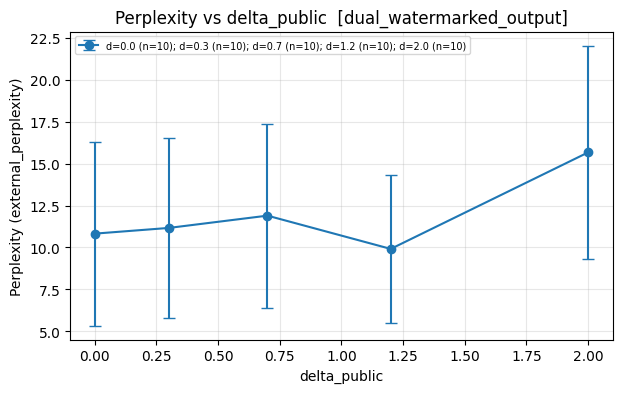

In [38]:
# ============================================================
# GRAPH 1 DATA - Perplexity vs delta_PUBLIC (private delta FIXED).
# BUG FIX vs old cell: the current DualWaterMarking class stores the
# private strength as self.delta_private; the old cell set dwm.delta_priv,
# which the class ignores (so all old "delta" runs were identical).
# Same prompts + same seed at every delta -> fair comparison.
# ============================================================
delta_to_metrics_df = {}
for delta_public in PUBLIC_DELTAS:
    dwm.delta_public = delta_public          # SWEPT variable
    dwm.delta_private = PRIVATE_DELTA_FIXED  # FIXED
    torch.manual_seed(SEED)
    sweep_df = dwm.watermark(prompts, include_single_layers=False)
    m_df, _ = evaluate_quality_table(
        sweep_df,
        text_cols=("dual_watermarked_output",),
        judge_model_name="gpt2-large",
        device=device,
    )
    m_df["delta_public"] = delta_public
    delta_to_metrics_df[delta_public] = m_df
    v = pd.to_numeric(m_df["external_perplexity"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    print(f"delta_public={delta_public}: n_valid_ppl={len(v)}  mean_ext_ppl={v.mean():.2f}")

plot_perplexity_vs_delta(delta_to_metrics_df)


In [39]:
# ---- z-score from the same match counts your detector already computes ----
def compute_z_score(match_count, total_positions, green_fraction=0.5):
    """
    Normal approximation to the binomial test your detector uses
    (matches ~ Binomial(total_positions, green_fraction) under H0).
    z = (matches - n*p) / sqrt(n*p*(1-p))
    """
    if total_positions == 0:
        return 0.0
    n, p = total_positions, green_fraction
    expected = n * p
    std = math.sqrt(n * p * (1 - p))
    if std == 0:
        return 0.0
    return (match_count - expected) / std


# ---- detection on a truncated token PREFIX (not a truncated string) ----
def detect_at_length(
    token_ids,
    length,
    key,
    vocab_size,
    green_fraction,
    prev_token_size,
):
    """
    Runs the exact same matching logic as `detect_private_watermark`, but
    restricted to the first `length` tokens of `token_ids`. Operating on
    token IDs directly (rather than decoding text, slicing, and
    re-encoding) avoids retokenization drift at the truncation boundary.
    Verified to produce identical match_count/num_positions/p_value to
    src.detection.kgw_detection.detect_private_watermark on full-length text.

    Returns the same dict shape as detect_private_watermark, plus 'z_score'.
    """
    truncated = token_ids[:length]
    matches = 0
    total_positions = 0
    for position in range(prev_token_size, len(truncated)):
        history = truncated[:position]
        preferred_set = derive_set(
            vocab_size=vocab_size,
            green_fraction=green_fraction,
            key=key,
            prev_tokens_size=prev_token_size,
            prev_tokens=history,
        )
        if truncated[position] in preferred_set:
            matches += 1
        total_positions += 1

    ownership_score = matches / total_positions if total_positions > 0 else 0.0
    p_value = (
        binomtest(k=matches, n=total_positions, p=green_fraction, alternative="greater").pvalue
        if total_positions > 0
        else 1.0
    )
    z_score = compute_z_score(matches, total_positions, green_fraction)

    return {
        "length": length,
        "ownership_score": ownership_score,
        "match_count": matches,
        "num_positions": total_positions,
        "p_value": p_value,
        "z_score": z_score,
    }


def detection_strength_vs_length(
    texts,
    tokenizer,
    key,
    vocab_size,
    green_fraction=0.5,
    prev_token_size=5,
    lengths=(50, 100, 200, 300),
):
    """
    For each text, tokenizes once, then evaluates detection at each
    prefix length in `lengths` (skipping lengths longer than the text).
    Returns a long-format DataFrame: columns = [text_id, length, z_score,
    ownership_score, p_value, num_positions].

    Use this to build the "z-score vs text length" plot required by the
    spec, using prefix evaluation at 50/100/200/300 tokens.
    """
    rows = []
    for i, text in enumerate(texts):
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        for length in lengths:
            if length > len(token_ids):
                continue  # text too short for this prefix length
            result = detect_at_length(
                token_ids, length, key, vocab_size, green_fraction, prev_token_size
            )
            result["text_id"] = i
            rows.append(result)
    return pd.DataFrame(rows)


def plot_zscore_vs_length(strength_df, save_path=None):
    """
    GRAPH 2: mean z-score (+/- std) at each prefix length, with per-length
    sample counts. Scores reported exactly as computed - no smoothing.
    """
    summary = strength_df.groupby("length")["z_score"].agg(["mean", "std", "count"]).reset_index()

    labels = [f"{int(r['length'])} tok (n={int(r['count'])})" for _, r in summary.iterrows()]
    plt.figure(figsize=(7, 4))
    plt.errorbar(summary["length"], summary["mean"], yerr=summary["std"],
                 marker="o", capsize=4, label="; ".join(labels))
    plt.xlabel("Text length (tokens)")
    plt.ylabel("z-score")
    plt.title("Detection strength (z-score) vs text length")
    plt.legend(fontsize=7)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


long generations: 10 (max_new_tokens=350)

per-length z-score summary:
         mean    std  count
length                     
50      0.477  0.723     10
100     1.416  0.839     10
200     2.554  1.279      9
300     3.493  1.115      8


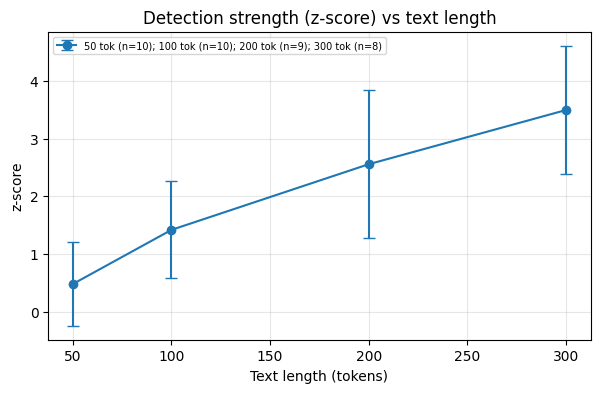

In [40]:
# Longer generations so the 50/100/200/300 prefix lengths aren't all skipped.
dwm.max_new_tokens = ROC_LENGTH
dwm.delta_public = 2.0
dwm.delta_private = PRIVATE_DELTA_FIXED
torch.manual_seed(SEED)
long_gen_df = dwm.watermark(prompts, include_single_layers=False)
print(f"long generations: {len(long_gen_df)} (max_new_tokens={dwm.max_new_tokens})")

strength_df = detection_strength_vs_length(
    long_gen_df["dual_watermarked_output"].tolist(),
    tokenizer,
    key,
    vocab_size,
    green_fraction=config["GREEN_FRACTION"],
    prev_token_size=config["PREV_TOKEN_SIZE"],
    lengths=(50, 100, 200, 300),
)

print("\nper-length z-score summary:")
print(strength_df.groupby("length")["z_score"].agg(["mean", "std", "count"]).round(3))
plot_zscore_vs_length(strength_df)


In [41]:
def build_roc_scores(
    watermarked_texts,
    clean_texts,
    tokenizer,
    key,
    vocab_size,
    green_fraction=0.5,
    prev_token_size=5,
    score_type="ownership_score",
):
    """
    Runs the detector on watermarked texts (label=1) and clean/non-watermarked
    texts (label=0), returns (y_true, y_score) arrays ready for sklearn's
    roc_curve. score_type: "ownership_score" or "z_score".
    """

    def score_one(text):
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        result = detect_at_length(
            token_ids, len(token_ids), key, vocab_size, green_fraction, prev_token_size
        )
        return result[score_type]

    y_true, y_score = [], []
    for t in watermarked_texts:
        y_true.append(1)
        y_score.append(score_one(t))
    for t in clean_texts:
        y_true.append(0)
        y_score.append(score_one(t))

    return np.array(y_true), np.array(y_score)


def plot_roc_curve(y_true, y_score, label="Layer 2 (KGW)", ax=None, save_path=None):
    """
    Plots the ROC curve and reports AUC + TPR @ FPR=1%.
    Returns dict with 'auc' and 'tpr_at_fpr_1pct'.
    Can be called multiple times with the same `ax` to overlay curves for
    Topic layer / KGW layer / Dual layer once those are available.
    """

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    tpr_at_1pct = float(np.interp(0.01, fpr, tpr))

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f}, TPR@1%FPR={tpr_at_1pct:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

    if standalone and save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    if standalone:
        plt.show()

    return {"auc": roc_auc, "tpr_at_fpr_1pct": tpr_at_1pct, "fpr": fpr, "tpr": tpr}

# ============================================================
# L1 (public/topic) detector + shared scoring for the ROC experiment
#
# L1 score = (# tokens in the routed topic's public greenlist) / (# tokens scored)
#
# VERIFIED: greenlists[topic]["all"] IS the exact set boosted at generation
# time - TopicBoostProcessor receives greenlists[topic][self.split] with
# split="all" (src/watermark/dual_layer.py _make_processor), and this is the
# same detection definition used in notebooks/08_topic_watermark_detection.ipynb.
# ============================================================
from src.watermark.first_layer import load_uniform_greenlists

_l1_green_sets = {t: frozenset(v["all"])
                  for t, v in load_uniform_greenlists("data/greenlist").items()}


def raw_l1_l2_scores(texts, topics, max_tokens=CLEAN_MAX_TOKENS):
    """Same detector interface for BOTH ROC classes.
    L1: fraction of tokens in the routed topic's public greenlist.
    L2: existing detect_at_length ownership_score (math unchanged);
        texts truncated to max_tokens (detector-valid length for clean C4)."""
    l1, l2 = [], []
    for text, topic in zip(texts, topics):
        token_ids = tokenizer.encode(text, add_special_tokens=False)[:max_tokens]
        if len(token_ids) == 0:
            l1.append(np.nan)
            l2.append(np.nan)
            continue
        gset = _l1_green_sets[topic]
        l1.append(sum(1 for tid in token_ids if tid in gset) / len(token_ids))
        res = detect_at_length(token_ids, len(token_ids), key, vocab_size,
                               config["GREEN_FRACTION"], config["PREV_TOKEN_SIZE"])
        l2.append(res["ownership_score"])
    return np.array(l1, dtype=float), np.array(l2, dtype=float)


def tpr_at_fpr_empirical(fpr, tpr, target=0.01):
    """Max TPR among ACTUAL ROC points with FPR <= target. No interpolation.
    Resolution caveat: with n_neg negatives, one false positive moves the
    empirical FPR by 1/n_neg (100 negatives -> 1 sample = 1%)."""
    fpr, tpr = np.asarray(fpr), np.asarray(tpr)
    mask = fpr <= target
    return float(tpr[mask].max()) if mask.any() else 0.0


ROC positives (watermarked) : 10
ROC negatives (clean C4)    : 10  (disjoint from FP slice)
L1 threshold (clean mean + 3sd): 0.2331


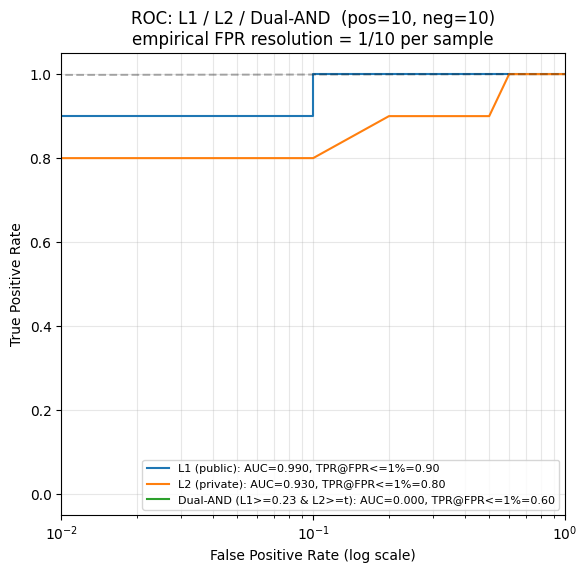


=== ROC summary ===
               auc  tpr_at_fpr_le_1pct
L1 (public)   0.99                 0.9
L2 (private)  0.93                 0.8
Dual-AND      0.00                 0.6

TPR@FPR<=1% caveat: with 10 negatives, one false positive = 10.00% FPR - treat these TPR values as coarse.


In [42]:
# ============================================================
# GRAPH 3 - balanced ROC: watermarked (350-token gens) vs INDEPENDENT clean C4
# Positives: dual-watermarked outputs (topic = topic used at generation time).
# Negatives: clean C4 reference_texts, DISJOINT from the FP-calibration slice,
#            routed through the project's own extract_topic.
# ============================================================
pos_texts = long_gen_df["dual_watermarked_output"].tolist()
pos_topics = long_gen_df["topic"].tolist()
neg_texts = clean_texts_roc[:N_SAMPLES]
neg_topics = [dwm.extract_topic(t)[0] for t in neg_texts]

assert len(pos_texts) > 0 and len(neg_texts) > 0, "ROC needs both classes"
print(f"ROC positives (watermarked) : {len(pos_texts)}")
print(f"ROC negatives (clean C4)    : {len(neg_texts)}  (disjoint from FP slice)")

l1_pos, l2_pos = raw_l1_l2_scores(pos_texts, pos_topics)
l1_neg, l2_neg = raw_l1_l2_scores(neg_texts, neg_topics)
assert np.isfinite(l1_pos).all() and np.isfinite(l2_pos).all(), "NaN scores in positive class"
assert np.isfinite(l1_neg).all() and np.isfinite(l2_neg).all(), "NaN scores in negative class"

# L1 operating threshold from the CLEAN distribution (reported on the plot)
t1 = float(l1_neg.mean() + 3 * l1_neg.std())
print(f"L1 threshold (clean mean + 3sd): {t1:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 6))
results = {}
for name, s_pos, s_neg in [
    ("L1 (public)", l1_pos, l1_neg),
    ("L2 (private)", l2_pos, l2_neg),
]:
    fpr, tpr, _ = roc_curve(np.r_[np.ones_like(s_pos), np.zeros_like(s_neg)],
                            np.r_[s_pos, s_neg])
    a = auc(fpr, tpr)
    t1p = tpr_at_fpr_empirical(fpr, tpr)
    results[name] = {"auc": a, "tpr_at_fpr_le_1pct": t1p}
    ax.plot(fpr, tpr, label=f"{name}: AUC={a:.3f}, TPR@FPR<=1%={t1p:.2f}")

# Dual-AND ROC: L1 gate fixed at t1, sweep the L2 threshold (actual points only)
t2_grid = np.unique(np.r_[l2_pos, l2_neg, np.inf])[::-1]  # descending
dtps = [float(((l2_pos >= t2) & (l1_pos >= t1)).mean()) for t2 in t2_grid]
dfps = [float(((l2_neg >= t2) & (l1_neg >= t1)).mean()) for t2 in t2_grid]
dfps_a, dtps_a = np.array(dfps), np.array(dtps)
order = np.argsort(dfps_a, kind="stable")
dual_auc = auc(dfps_a[order], dtps_a[order])
dual_t1p = tpr_at_fpr_empirical(dfps_a, dtps_a)
results["Dual-AND"] = {"auc": dual_auc, "tpr_at_fpr_le_1pct": dual_t1p}
ax.step(dfps_a, dtps_a, where="post",
        label=f"Dual-AND (L1>={t1:.2f} & L2>=t): AUC={dual_auc:.3f}, TPR@FPR<=1%={dual_t1p:.2f}")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xscale("log")
ax.set_xlim(1.0 / (10 * max(len(neg_texts), 1)), 1.0)
ax.set_xlabel("False Positive Rate (log scale)")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC: L1 / L2 / Dual-AND  (pos={len(pos_texts)}, neg={len(neg_texts)})\n"
             f"empirical FPR resolution = 1/{len(neg_texts)} per sample")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.show()

print("\n=== ROC summary ===")
print(pd.DataFrame(results).T.round(4))
print(f"\nTPR@FPR<=1% caveat: with {len(neg_texts)} negatives, one false positive = "
      f"{1.0 / len(neg_texts):.2%} FPR - treat these TPR values as coarse.")
roc_scores = {"pos": {"L1": l1_pos, "L2": l2_pos},
              "neg": {"L1": l1_neg, "L2": l2_neg}, "t1": t1}


In [43]:
# ============================================================
# FP CALIBRATION defs (up to FP_MAX_SAMPLES independent clean C4 samples)
# Clean loading now lives in the CLEAN C4 TEXTS cell (word_count >= 30,
# no 80-word cap - the old filter left n=2, which made every FPR=0
# meaningless). Clean texts are truncated to CLEAN_MAX_TOKENS tokens here.
# ============================================================
def run_fp_calibration(clean_texts, tokenizer, key, vocab_size,
                       green_fraction=0.5, prev_token_size=5,
                       thresholds=(0.5, 0.55, 0.6, 0.65, 0.7),
                       p_value_thresholds=(0.01, 0.05, 0.1),
                       max_tokens=CLEAN_MAX_TOKENS):
    """Score each clean text ONCE, then sweep thresholds over cached scores.
    Returns (calibration_df, scored_df); calibration_df columns:
    [threshold, p_value, n, fp_count, fpr] with fpr = fp_count / n."""
    scored = []
    for text in clean_texts:
        token_ids = tokenizer.encode(text, add_special_tokens=False)[:max_tokens]
        scored.append(detect_at_length(token_ids, len(token_ids), key, vocab_size,
                                       green_fraction, prev_token_size))
    scored_df = pd.DataFrame(scored)

    rows = []
    for th in thresholds:
        for pth in p_value_thresholds:
            fp_mask = (scored_df["ownership_score"] > th) & (scored_df["p_value"] < pth)
            fp_count = int(fp_mask.sum())
            n = len(scored_df)
            rows.append({"threshold": th, "p_value": pth, "n": n,
                         "fp_count": fp_count,
                         "fpr": (fp_count / n) if n else float("nan")})
    return pd.DataFrame(rows), scored_df


def plot_fp_threshold_stability(fp_calibration_df, save_path=None):
    """FPR vs ownership threshold, one line per p_value threshold, n in legend."""
    plt.figure(figsize=(7, 4))
    for pth, group in fp_calibration_df.groupby("p_value"):
        group = group.sort_values("threshold")
        n = int(group["n"].iloc[0])
        plt.plot(group["threshold"], group["fpr"], marker="o", label=f"p < {pth} (n={n})")
    plt.xlabel("Ownership score threshold")
    plt.ylabel("False Positive Rate (fp_count / n)")
    plt.title("FP calibration on clean C4 (threshold stability)")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


len(clean_texts) = 500
clean ownership_score: mean=0.4960 max=0.6051 n=500


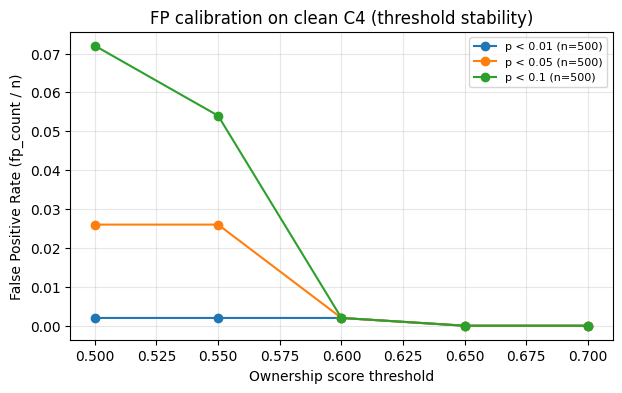

,threshold,p_value,n,fp_count,fpr
0,0.50,0.01,500,1,0.002
1,0.50,0.05,500,13,0.026
2,0.50,0.10,500,36,0.072
3,0.55,0.01,500,1,0.002
4,0.55,0.05,500,13,0.026
5,0.55,0.10,500,27,0.054
6,0.60,0.01,500,1,0.002
7,0.60,0.05,500,1,0.002
8,0.60,0.10,500,1,0.002
9,0.65,0.01,500,0,0.000


In [44]:
print(f"len(clean_texts) = {len(clean_texts_fp)}")
fp_calibration_df, scored_clean_df = run_fp_calibration(
    clean_texts_fp,
    tokenizer,
    key,
    vocab_size,
    green_fraction=config["GREEN_FRACTION"],
    prev_token_size=config["PREV_TOKEN_SIZE"],
)
if fp_calibration_df["n"].min() < 50:
    print(f"WARNING: FP calibration n={int(fp_calibration_df['n'].min())} < 50 "
          f"- too small for meaningful interpretation")
print(f"clean ownership_score: mean={scored_clean_df['ownership_score'].mean():.4f} "
      f"max={scored_clean_df['ownership_score'].max():.4f} "
      f"n={len(scored_clean_df)}")
plot_fp_threshold_stability(fp_calibration_df)
fp_calibration_df


valid semantic comparisons : 10 / 10
sim_plain       : mean=0.9783 std=0.0046 n=10
sim_watermarked : mean=0.9749 std=0.0077 n=10


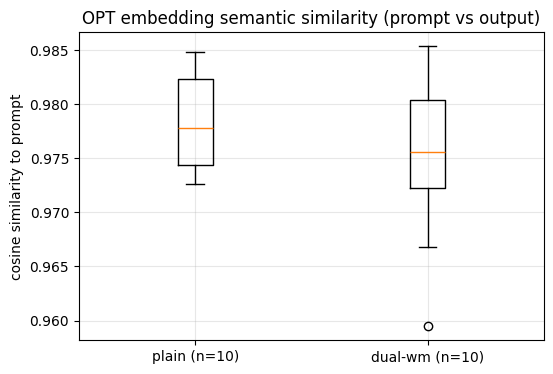

,prompt,sim_plain,sim_watermarked
0,"""Whoever gets him, they'll be getting a good o...",0.975098,0.959473
1,8i announced today it has launched a web playe...,0.973633,0.977051
2,The Arlington County Board plans to vote Satur...,0.980469,0.981445
3,The Hawaii man who was fired after issuing the...,0.984863,0.982910
4,Shania Twain expected to break the charts with...,0.982910,0.966797
5,A version of this article appeared in the prin...,0.979980,0.976074
6,A blind man in his 60s is searching for the yo...,0.983887,0.985352
7,"After Kevin’s horrific leg injury, everyone is...",0.972656,0.972168
8,This month some important Walmart news did not...,0.975586,0.975098
9,University of Utah track and field athlete Lau...,0.974121,0.972656


In [45]:
# ============================================================
# GRAPH 5 - Semantic preservation
# "OPT embedding semantic similarity": mean-pooled OPT input embeddings,
# cosine similarity between prompt and each output. This is a simple,
# transparent geometric measure - NOT a state-of-the-art semantic metric.
# ============================================================
@torch.no_grad()
def opt_semantic_similarity(text_a, text_b):
    ids_a = tokenizer.encode(str(text_a), add_special_tokens=False)
    ids_b = tokenizer.encode(str(text_b), add_special_tokens=False)
    if not ids_a or not ids_b:
        return float("nan")
    emb = model.get_input_embeddings().weight
    va = emb[ids_a].mean(dim=0)
    va = va / va.norm()
    vb = emb[ids_b].mean(dim=0)
    vb = vb / vb.norm()
    return torch.dot(va, vb).item()

sim_plain = [opt_semantic_similarity(p, o)
             for p, o in zip(gen_df["prompt"], gen_df["plain_output"])]
sim_wm = [opt_semantic_similarity(p, o)
          for p, o in zip(gen_df["prompt"], gen_df["dual_watermarked_output"])]

sem_df = pd.DataFrame({
    "prompt": gen_df["prompt"],
    "sim_plain": sim_plain,
    "sim_watermarked": sim_wm,
})
valid = sem_df.dropna(subset=["sim_plain", "sim_watermarked"])
print(f"valid semantic comparisons : {len(valid)} / {len(sem_df)}")
if len(valid):
    print(f"sim_plain       : mean={valid['sim_plain'].mean():.4f} "
          f"std={valid['sim_plain'].std():.4f} n={len(valid)}")
    print(f"sim_watermarked : mean={valid['sim_watermarked'].mean():.4f} "
          f"std={valid['sim_watermarked'].std():.4f} n={len(valid)}")

data = [valid["sim_plain"].dropna(), valid["sim_watermarked"].dropna()]
if all(len(d) for d in data):
    plt.figure(figsize=(6, 4))
    plt.boxplot(data)
    plt.xticks([1, 2], [f"plain (n={len(data[0])})", f"dual-wm (n={len(data[1])})"])
    plt.ylabel("cosine similarity to prompt")
    plt.title("OPT embedding semantic similarity (prompt vs output)")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("WARNING: not enough valid values to draw the semantic box plot")
sem_df


In [46]:
len(clean_texts_fp), len(clean_texts_roc)

(500, 10)

In [47]:
fp_calibration_df

,threshold,p_value,n,fp_count,fpr
0,0.50,0.01,500,1,0.002
1,0.50,0.05,500,13,0.026
2,0.50,0.10,500,36,0.072
3,0.55,0.01,500,1,0.002
4,0.55,0.05,500,13,0.026
5,0.55,0.10,500,27,0.054
6,0.60,0.01,500,1,0.002
7,0.60,0.05,500,1,0.002
8,0.60,0.10,500,1,0.002
9,0.65,0.01,500,0,0.000


In [48]:
# ============================================================
# FINAL SANITY CHECKS - gate for switching to N_SAMPLES = 100
# ============================================================
problems, soft_warnings = [], []

def check(name, ok, detail="", warn_only=False):
    tag = "OK  " if ok else ("WARN" if warn_only else "FAIL")
    print(f"[{tag}] {name} {detail}")
    if not ok:
        (soft_warnings if warn_only else problems).append(name)

check("N_SAMPLES configured", N_SAMPLES in (10, 100), f"= {N_SAMPLES}")
check("prompts loaded", len(prompts) > 0, f"n={len(prompts)}")
check("generated outputs match prompts", len(gen_df) == len(prompts), f"n={len(gen_df)}")
check("no zero-length generations",
      bool((gen_df["dual_watermarked_output"].str.len() > 0).all()
           and (gen_df["plain_output"].str.len() > 0).all()))
_num = metrics_df.select_dtypes(include=[np.number])
check("no inf in quality metrics", int(np.isinf(_num).sum().sum()) == 0,
      f"inf_count={int(np.isinf(_num).sum().sum())}")
check("NaN in quality metrics", int(_num.isna().sum().sum()) == 0,
      f"nan_count={int(_num.isna().sum().sum())} (excluded from means)", warn_only=True)
check("clean FP texts non-empty", len(clean_texts_fp) > 0, f"n={len(clean_texts_fp)}")
check("clean ROC texts non-empty", len(clean_texts_roc) > 0, f"n={len(clean_texts_roc)}")
check("FP calibration n >= 50",
      bool(len(fp_calibration_df)) and int(fp_calibration_df["n"].min()) >= 50,
      f"min_n={int(fp_calibration_df['n'].min()) if len(fp_calibration_df) else 0}",
      warn_only=True)
check("ROC both classes present", len(pos_texts) > 0 and len(neg_texts) > 0,
      f"pos={len(pos_texts)} neg={len(neg_texts)}")
check("ROC scores finite",
      bool(np.isfinite(roc_scores["pos"]["L2"]).all()
           and np.isfinite(roc_scores["neg"]["L2"]).all()
           and np.isfinite(roc_scores["pos"]["L1"]).all()
           and np.isfinite(roc_scores["neg"]["L1"]).all()))
check("delta_public actually swept",
      sorted(delta_to_metrics_df.keys()) == sorted(PUBLIC_DELTAS),
      f"{sorted(delta_to_metrics_df.keys())}")
check("semantic comparisons valid", len(valid) > 0, f"n={len(valid)}")

print()
if problems:
    raise AssertionError(f"SMOKE TEST FAILED: {problems}")
print("All sanity checks passed." + (f" Warnings: {soft_warnings}" if soft_warnings else ""))
print("You may now manually set N_SAMPLES = 100 for the final run.")


[OK  ] N_SAMPLES configured = 10
[OK  ] prompts loaded n=10
[OK  ] generated outputs match prompts n=10
[OK  ] no zero-length generations 
[OK  ] no inf in quality metrics inf_count=0
[OK  ] NaN in quality metrics nan_count=0 (excluded from means)
[OK  ] clean FP texts non-empty n=500
[OK  ] clean ROC texts non-empty n=10
[OK  ] FP calibration n >= 50 min_n=500
[OK  ] ROC both classes present pos=10 neg=10
[OK  ] ROC scores finite 
[OK  ] delta_public actually swept [0.0, 0.3, 0.7, 1.2, 2.0]
[OK  ] semantic comparisons valid n=10

All sanity checks passed.
You may now manually set N_SAMPLES = 100 for the final run.
